# What is the most optimal skill to learn for Data Analysts?

## Methodology

1. Continue from last notebook to find percent of postings with skill
2. Visualize median salary vs percent skill demand
3. (Optional) Determine if certain technologies are more prevalent

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

/opt/anaconda3/envs/CursoLukeB/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Filter de df for Data Analysts in Spain only
df_DA_ES = df[(df['job_country'] == 'Spain') & (df['job_title_short'] == 'Data Analyst')].copy()

# Drop NA values for their salaries
df_DA_ES = df_DA_ES.dropna(subset=['salary_year_avg'])

# Explode the job skills column
df_DA_ES = df_DA_ES.explode('job_skills')

In [8]:
# Find the most optimal skills

df_DA_ES_skills = df_DA_ES.groupby(by='job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DA_ES_skills = df_DA_ES_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

DA_job_count = len(df_DA_ES)

df_DA_ES_skills['skill_percent'] = df_DA_ES_skills['skill_count'] / DA_job_count * 100

skill_percent = 2 #to compare various skills, with 5% only 3 skills were shown

df_DA_ES_skills_hight_demand = df_DA_ES_skills[df_DA_ES_skills['skill_percent'] > skill_percent]

df_DA_ES_skills_hight_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,17,89100.0,15.044248
python,14,98500.0,12.389381
tableau,9,98500.0,7.964602
excel,5,72900.0,4.424779
power bi,4,73352.0,3.539823
pandas,4,108087.5,3.539823
looker,4,111175.0,3.539823
airflow,3,98500.0,2.654867
jupyter,3,105000.0,2.654867


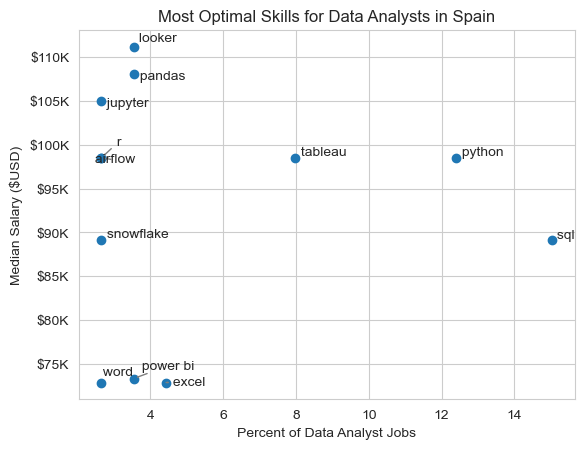

In [9]:
from adjustText import adjust_text

plt.scatter(df_DA_ES_skills_hight_demand['skill_percent'], df_DA_ES_skills_hight_demand['median_salary'])
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Salary ($USD)')
plt.title('Most Optimal Skills for Data Analysts in Spain')

# Get current axes, set limits, and format axes
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))  # Example formatting y-axis

# Add labels to points and collect them in a list
texts = []
for i, txt in enumerate(df_DA_ES_skills_hight_demand.index):
    texts.append(plt.text(df_DA_ES_skills_hight_demand['skill_percent'].iloc[i], df_DA_ES_skills_hight_demand['median_salary'].iloc[i], " " + txt))

# Adjust text to avoid overlap and add arrows
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.show()

In [11]:
#We're going to add color labels based on technology.
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing value
            technology_dict[key] += value
        else:                       # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

In [12]:
# turn dictionary into dataframe
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,power bi
0,analyst_tools,excel
0,analyst_tools,qlik
0,analyst_tools,alteryx
0,analyst_tools,cognos
...,...,...
9,sync,rocketchat
9,sync,google chat
9,sync,microsoft teams
9,sync,zoom


In [23]:
# merge df_DA_skills and df_technology
df_DA_skills_tech_high_demand = df_DA_ES_skills.merge(df_technology, left_on='job_skills', right_on='skills')

df_DA_skills_tech_high_demand = df_DA_skills_tech_high_demand[df_DA_skills_tech_high_demand['skill_percent'] > skill_percent]
df_DA_skills_plot = df_DA_skills_tech_high_demand
df_DA_skills_plot

,skill_count,median_salary,skill_percent,technology,skills
0,17,89100.0,15.044248,programming,sql
1,14,98500.0,12.389381,programming,python
2,9,98500.0,7.964602,analyst_tools,tableau
3,5,72900.0,4.424779,analyst_tools,excel
4,4,73352.0,3.539823,analyst_tools,power bi
5,4,108087.5,3.539823,libraries,pandas
6,4,111175.0,3.539823,analyst_tools,looker
7,3,98500.0,2.654867,libraries,airflow
8,3,105000.0,2.654867,libraries,jupyter
9,3,89100.0,2.654867,cloud,snowflake


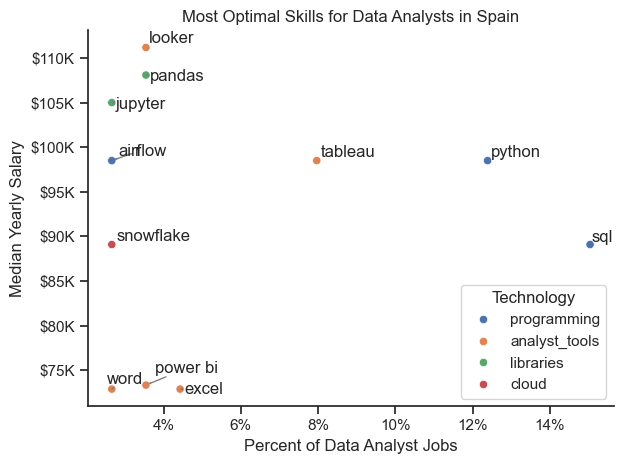

In [25]:
sns.scatterplot(
    data=df_DA_skills_plot,
    x='skill_percent',
    y='median_salary',
    hue='technology'
)

sns.despine()
sns.set_theme(style='ticks')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DA_ES_skills_hight_demand.index):
    texts.append(plt.text(df_DA_ES_skills_hight_demand['skill_percent'].iloc[i], df_DA_ES_skills_hight_demand['median_salary'].iloc[i], txt))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in Spain')
plt.legend(title='Technology')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

# Adjust layout and display plot
plt.tight_layout()
plt.show()